# Text-to-SQL Agent — deepagents' workflow as GOAP

A Tier 2 tutorial that GOAPifies the
[text-to-sql-agent example](https://github.com/langchain-ai/deepagents/tree/main/examples/text-to-sql-agent)
from deepagents.  The original agent threads a single LLM through
schema exploration, query drafting, execution, and refinement via
prompt engineering.  LangGOAP does the same thing with an
explicit GOAP plan where each phase is an `ActionSpec` with real
preconditions and effects.

This tutorial spotlights three planning features at once:

1. **Action sequencing** — `explore_schema` must fire before any
   draft action because every draft preconditions on
   `schema_known=True`.
2. **Replanning on execution failure** — a cheap
   `fast_query_attempt` drafts a SQL string with a deliberate
   typo.  Running it raises `sqlite3.OperationalError`, so the
   executor blacklists the action and the planner falls back on
   the more expensive `careful_query_attempt`.
3. **`effect_validator` as a soundness check** — the fallback
   action attaches a validator that verifies the query produced
   at least one row, demonstrating how postcondition checks
   complement preconditions and declared effects.

The tutorial uses `sqlite3` with an in-memory connection seeded
from a compact Chinook subset (`Customer` + `Invoice`) so nothing
is written to disk and the "top spenders" answer is
deterministic.

In [ ]:
import langgoap

# The fast-query-attempt action deliberately raises so the executor
# blacklists it and the planner can replan; silence the expected
# warning so the notebook output stays clean.
langgoap.set_log_level("ERROR")

from langgoap import GoapGraph
from tutorial_examples.data.sql_query_instance import (
    CUSTOMER_ROWS,
    EXPECTED_TOP_SPENDERS,
    INVOICE_ROWS,
)
from tutorial_examples.sql_query_agent import (
    CAREFUL_QUERY_SQL,
    FAST_QUERY_SQL,
    build_in_memory_db,
    sql_query_agent_actions,
    sql_query_agent_goal,
    sql_query_agent_start,
)

print(f'Customers seeded: {len(CUSTOMER_ROWS)}')
for cid, first, last, country in CUSTOMER_ROWS:
    total_invoices = sum(1 for r in INVOICE_ROWS if r[1] == cid)
    total_spend = sum(r[2] for r in INVOICE_ROWS if r[1] == cid)
    print(f'  {cid}  {first} {last:<15s} ({country:<14s})  invoices={total_invoices}  spent={total_spend:.2f}')

## 1. The question and the expected answer

The user wants the **three customers who have spent the most**.
Because the data is hand-picked the answer is deterministic:

In [2]:
for rank, (name, spent) in enumerate(EXPECTED_TOP_SPENDERS, start=1):
    print(f'  #{rank}  {name:<22s}  {spent:6.2f}')

  #1  Helena Holý              49.62
  #2  Richard Cunningham       47.62
  #3  Luís Gonçalves           39.62


## 2. The action catalog

Three actions model the classic text-to-SQL workflow:

| Action | Precondition | Effect | Cost | Notes |
|--------|-------------|--------|------|-------|
| `explore_schema` | `schema_known=False` | `schema_known=True` | 1 | Introspects `sqlite_master` |
| `fast_query_attempt` | `schema_known=True` | `answer_ready=True` | 1 | Drafts a query with a **misspelled column** — raises `OperationalError` |
| `careful_query_attempt` | `schema_known=True` | `answer_ready=True` | 3 | Correct draft + `effect_validator` non-empty check |

The cost delta is the whole story: A* prefers the cheap
(`explore_schema` → `fast_query_attempt`, total cost 2) path and
only falls back on the careful draft after the fast one fails at
runtime.

In [3]:
conn = build_in_memory_db()
actions = sql_query_agent_actions(conn)
for a in actions:
    validator = 'yes' if a.effect_validator is not None else 'no'
    print(f'  {a.name:<24s}  pre={dict(a.preconditions)}  eff={dict(a.effects)}  cost={a.cost}  validator={validator}')

  explore_schema            pre={'schema_known': False}  eff={'schema_known': True}  cost=1.0  validator=no
  fast_query_attempt        pre={'schema_known': True, 'answer_ready': False}  eff={'answer_ready': True}  cost=1.0  validator=no
  careful_query_attempt     pre={'schema_known': True, 'answer_ready': False}  eff={'answer_ready': True}  cost=3.0  validator=yes


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

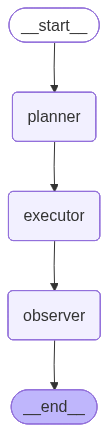

In [4]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 3. Plan the cheap path

A* doesn't know the fast query is broken — cost is all it
sees.  The initial plan is `explore_schema` → `fast_query_attempt`
at total cost 2.

In [5]:
from langgoap.planner.astar import plan as astar_plan
from langgoap.state import PlanningState

initial_plan = astar_plan(
    PlanningState.from_dict(sql_query_agent_start()),
    sql_query_agent_goal(),
    actions,
)
print('Initial plan:')
for step, a in enumerate(initial_plan.actions, start=1):
    print(f'  {step}. {a.name}  (cost {a.cost})')
print(f'Total cost: {initial_plan.total_cost}')

Initial plan:
  1. explore_schema  (cost 1.0)
  2. fast_query_attempt  (cost 1.0)
Total cost: 2.0


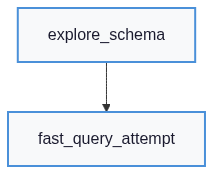

In [6]:
display(Image(initial_plan.draw_mermaid_png()))

## 4. Peek at the drafted SQL strings

`fast_query_attempt` uses a column that doesn't exist —
`c.Frst_Name`.  sqlite will reject it the moment the executor
calls `conn.execute(...)`:

In [7]:
print('FAST (broken):')
print(FAST_QUERY_SQL)
print()
print('CAREFUL (correct):')
print(CAREFUL_QUERY_SQL)

FAST (broken):
SELECT c.Frst_Name, SUM(i.Total) AS Spent
FROM Customer c JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY Spent DESC
LIMIT 3

CAREFUL (correct):
SELECT c.FirstName || ' ' || c.LastName AS Name,
       ROUND(SUM(i.Total), 2) AS Spent
FROM Customer c JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY Spent DESC
LIMIT 3


## 5. Run the full GOAP loop

Running the plan exercises the whole loop — executor, observer,
blacklist, replanner — on the sqlite connection we just built.

In [8]:
graph = GoapGraph(actions=actions)
result = graph.invoke(
    goal=sql_query_agent_goal(),
    world_state=sql_query_agent_start(),
)

print(f'Status      : {result["status"]}')
print(f'Replans     : {result.get("replan_count", 0)}')
print(f'Blacklisted : {list(result.get("blacklisted_actions", []))}')
print()
print('Execution history:')
for h in result['execution_history']:
    status = 'OK' if h.success else f'FAIL ({h.error})'
    print(f'  {h.action_name:<24s}  {status}')

Status      : goal_achieved
Replans     : 1
Blacklisted : ['fast_query_attempt']

Execution history:
  explore_schema            OK
  fast_query_attempt        FAIL (no such column: c.Frst_Name)
  careful_query_attempt     OK


## 6. The answer the agent actually returned

On success the executor stores the drafted SQL and its result set
into world state under `sql` and `results`.  The observer checks
`answer_ready=True` and routes to the terminal node.

In [9]:
print(f'SQL used    :\n{result["world_state"]["sql"]}')
print()
print('Top spenders:')
for rank, (name, spent) in enumerate(result['world_state']['results'], start=1):
    print(f'  #{rank}  {name:<22s}  {spent:6.2f}')

SQL used    :
SELECT c.FirstName || ' ' || c.LastName AS Name,
       ROUND(SUM(i.Total), 2) AS Spent
FROM Customer c JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY Spent DESC
LIMIT 3

Top spenders:
  #1  Helena Holý              49.62
  #2  Richard Cunningham       47.62
  #3  Luís Gonçalves           39.62


## 7. The `effect_validator` soundness check

`careful_query_attempt` ships with a validator that rejects
*empty* result sets.  Running the same action against an unseeded
database exercises the failure branch — the executor marks the
action failed and replanning takes over.  We drive the validator
directly here so the pattern is visible without depending on the
internal action-failed machinery:

In [10]:
empty_conn = build_in_memory_db(seed=False)
empty_actions = {a.name: a for a in sql_query_agent_actions(empty_conn)}
careful = empty_actions['careful_query_attempt']

raw = careful.execute({'schema_known': True, 'answer_ready': False})
print(f'Query returned    : {raw["results"]}')
print(f'Validator verdict : {careful.validate_effects({}, raw)}')

Query returned    : []
Validator verdict : False


`False` from the validator tells the executor the action did not
actually accomplish what it claimed, triggering the same
blacklist + replan dance that `fast_query_attempt` used in the
happy-path run above.

## 8. Natural-language intake

As with the other Tier 2 tutorials, LangGOAP can take a plain
English request and turn it into a `GoalSpec` via
`GoalInterpreter`.  For a runnable notebook we use
`FakeStructuredModel` so there is no API key dependency — swap in
`ChatOpenAI`, `ChatAnthropic`, or any `BaseChatModel` subclass in
production.

In [11]:
from langgoap import GoalInterpreter, InterpretedGoal
from langgoap.testing import FakeStructuredModel

llm = FakeStructuredModel(
    response=InterpretedGoal(
        conditions={'answer_ready': True},
        constraints=[],
        objectives=[],
        reasoning='The user wants a concrete answer, so answer_ready must be True.',
    )
)

nl_actions = sql_query_agent_actions(build_in_memory_db())
nl_result = GoapGraph(actions=nl_actions).invoke_nl(
    'Show me the three customers who have spent the most.',
    llm=llm,
    world_state=sql_query_agent_start(),
)

print(f'Status : {nl_result["status"]}')
for rank, (name, spent) in enumerate(nl_result['world_state']['results'], start=1):
    print(f'  #{rank}  {name:<22s}  {spent:6.2f}')

Status : goal_achieved
  #1  Helena Holý              49.62
  #2  Richard Cunningham       47.62
  #3  Luís Gonçalves           39.62


## Summary

Three actions, one deliberate typo, and an sqlite connection are
enough to demonstrate the core LangGOAP recovery story:

- **Sequencing** falls out of preconditions — the draft actions
  simply cannot fire until `explore_schema` sets `schema_known`.
- **Blacklisting** turns a one-off exception into a planning
  signal without the user having to catch anything.
- **`effect_validator`** acts as a belt-and-braces soundness
  check for actions whose success can only be verified after the
  fact — "the query ran" is not the same as "the query was
  meaningful".

The integration test that pins this tutorial lives at
`tests/integration/test_sql_query_agent.py`.